# Importing Libraries

In [104]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.figure_factory as ff
import textwrap
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
import category_encoders as ce
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, f1_score, recall_score, roc_auc_score, classification_report
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.combine import SMOTEENN
pd.options.plotting.backend = "plotly"

from xgboost import XGBClassifier, plot_importance
from catboost import CatBoostClassifier, Pool, metrics, cv

plt.style.use('seaborn-v0_8-darkgrid')

# Loading Dataset

In [105]:
df = pd.read_csv('Data.csv', index_col='id')
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


# Exploratory Data Analysis

## Basic Data Exploration

In [106]:
df.shape

(165034, 13)

In [107]:
df.dtypes

CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                float64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard          float64
IsActiveMember     float64
EstimatedSalary    float64
Exited               int64
dtype: object

In [108]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [109]:
df.isna().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [110]:
df.drop_duplicates(subset=['CustomerId', 'CreditScore', 'Age', 'Gender', 'Geography', 'Surname', 'Tenure', 'Balance', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited'], inplace=True)

In [111]:
numerical_cols = [cname for cname in df.columns if df[cname].dtype in ['int64', 'float64']]
categorical_cols = [cname for cname in df.columns if df[cname].dtype == "object"]

print('Numerical Columns: ', numerical_cols)
print('Categorical Columns: ', categorical_cols)

Numerical Columns:  ['CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Categorical Columns:  ['Surname', 'Geography', 'Gender']


In [112]:
unique_counts = df[categorical_cols].nunique()
unique_values = df[categorical_cols].apply(lambda x: x.unique())

pd.DataFrame({'Number of Unique Values': unique_counts, 'Unique Values': unique_values})

,Number of Unique Values,Unique Values
Surname,2797,"[Okwudilichukwu, Okwudiliolisa, Hsueh, Kao, Ch..."
Geography,3,"[France, Spain, Germany]"
Gender,2,"[Male, Female]"


In [113]:
df['Surname'].value_counts()

Hsia         2456
T'ien        2282
Hs?          1611
Maclean      1577
Kao          1574
             ... 
Donoghue        1
Culbreth        1
Krischock       1
Lindon          1
Elkins          1
Name: Surname, Length: 2797, dtype: int64

In [114]:
df['Geography'].value_counts()

France     94122
Spain      36177
Germany    34594
Name: Geography, dtype: int64

In [115]:
df['Gender'].value_counts()

Male      93068
Female    71825
Name: Gender, dtype: int64

In [116]:
df['Exited'].value_counts()

0    129994
1     34899
Name: Exited, dtype: int64

## Data Viz

In [17]:
# Create countplot for the Gender
histogram1 = go.Histogram(x=df['Gender'], name='Gender')

# Create countplot for the Geography
histogram2 = go.Histogram(x=df['Geography'], name='Geography')

# Create subplots
fig = make_subplots(rows=1, cols=2)

# Add countplot for the Gender to subplot
fig.add_trace(histogram1, row=1, col=1)

# Add countplot for the Geography to subplot
fig.add_trace(histogram2, row=1, col=2)

# Update layout
fig.update_layout(title='Countplots')

# Show plot
fig.show()

Output hidden; open in https://colab.research.google.com to view.

***Key Observation***
- There are more male customers than female
- Most of them are from France

In [18]:
fig = px.histogram(df, x='Gender', color='Exited', facet_col='Geography')

fig.update_layout(title='Countplots of Gender and Geography with Exited',
                  xaxis=dict(title='Gender'), yaxis=dict(title='Count'))

fig.show()

***Key Observation***
- Female customers are more likely to exit than males.  

In [19]:
df_hist = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']]

fig = make_subplots(rows=2, cols=4, subplot_titles=df_hist.columns)

fig.add_trace(go.Histogram(x=df['CreditScore'], name='CreditScore'), row=1, col=1)
fig.add_trace(go.Histogram(x=df['Age'], name='Age'), row=1, col=2)
fig.add_trace(go.Histogram(x=df['Tenure'], name='Tenure'), row=1, col=3)
fig.add_trace(go.Histogram(x=df['Balance'], name='Balance'), row=1, col=4)
fig.add_trace(go.Histogram(x=df['NumOfProducts'], name='NumOfProducts'), row=2, col=1)
fig.add_trace(go.Histogram(x=df['HasCrCard'], name='HasCrCard'), row=2, col=2)
fig.add_trace(go.Histogram(x=df['IsActiveMember'], name='IsActiveMember'), row=2, col=3)
fig.add_trace(go.Histogram(x=df['EstimatedSalary'], name='EstimatedSalary'), row=2, col=4)

# Update layout
fig.update_layout(title='Individual Displots of Eight Columns', showlegend=False)
fig.update_xaxes(title_text='Value', row=2, col=1)
fig.update_yaxes(title_text='Probability Density', row=1, col=1)

# Show plot
fig.show()

Output hidden; open in https://colab.research.google.com to view.

***Key Observation***
- Most customers age are between 25 to 45 years old.
- There are a lot of customers with balance 0.
- 1 and 2 are the most frequent value for number of products.

In [20]:
df_hist = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'IsActiveMember', 'EstimatedSalary']]

fig = make_subplots(rows=2, cols=4, subplot_titles=df_hist.columns)

fig.add_trace(go.Box(x=df['CreditScore'], name='CreditScore'), row=1, col=1)
fig.add_trace(go.Box(x=df['Age'], name='Age'), row=1, col=2)
fig.add_trace(go.Box(x=df['Tenure'], name='Tenure'), row=1, col=3)
fig.add_trace(go.Box(x=df['Balance'], name='Balance'), row=1, col=4)
fig.add_trace(go.Box(x=df['NumOfProducts'], name='NumOfProducts'), row=2, col=1)
fig.add_trace(go.Box(x=df['IsActiveMember'], name='IsActiveMember'), row=2, col=2)
fig.add_trace(go.Box(x=df['EstimatedSalary'], name='EstimatedSalary'), row=2, col=3)

# Update layout
fig.update_layout(title='Individual Box Plots of Seven Columns', showlegend=False)

# Rotate y-axis labels
fig.update_yaxes(tickangle=90)

# Show plot
fig.show()


Output hidden; open in https://colab.research.google.com to view.

In [21]:
# Calculate Pearson correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Round the correlation coefficient values to two decimal places
corr_matrix_rounded = corr_matrix.round(2)

# Create a heatmap
fig = ff.create_annotated_heatmap(
    z=corr_matrix_rounded.values,
    x=corr_matrix_rounded.columns.tolist(),
    y=corr_matrix_rounded.columns.tolist(),
    colorscale='Viridis',
    showscale=True  # Show color scale
)

# Update layout
fig.update_layout(
    title='Pearson Correlation Heatmap',
    xaxis=dict(title='Features'),
    yaxis=dict(title='Features'),
    font=dict(size=10),  # Adjust font size
    margin=dict(t=100, r=100),  # Adjust margins to prevent overlapping
)

# Show plot
fig.show()

***Key Observation***
- Age and Exited are positively correlated.
- Balance and NumOfProducts are negetively correlated.
- IsActiveMember and NumOfProducts are slightly negetively correlated with Exited.

# Data preprocessing

- Dropping CustomerId and Surname because they should not make impact to the model.

In [117]:
df.drop(columns=['CustomerId', 'Surname'], inplace=True)

***Data spliting***

In [118]:
X = df.drop(columns=['Exited'])
y = df['Exited']

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

***Target Encoding***

- James-Stein Encoder used for the categorical variables.
- model is 'binary' and 4 sigma value is used for experiment.

In [120]:
# sigma_values = [0.1, 0.5, 1.0, 2.0]

encoder = ce.JamesSteinEncoder(cols=["Gender", "Geography"], model='binary', sigma=0.1)
X_train = encoder.fit_transform(X_train, y_train)
X_test = encoder.transform(X_test)

***Mutual Information***
- Mutual Information can help us to understand the relative potential of a feature as a predictor of the target.

In [122]:
def make_mi_scores(X, y):
    mi_scores = mutual_info_classif(X, y)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


mi_scores = make_mi_scores(X_train, y_train)
mi_scores

NumOfProducts      0.098301
Age                0.083545
IsActiveMember     0.039121
Gender             0.025054
Geography          0.024529
HasCrCard          0.019057
Balance            0.016348
EstimatedSalary    0.007483
CreditScore        0.001889
Tenure             0.001254
Name: MI Scores, dtype: float64

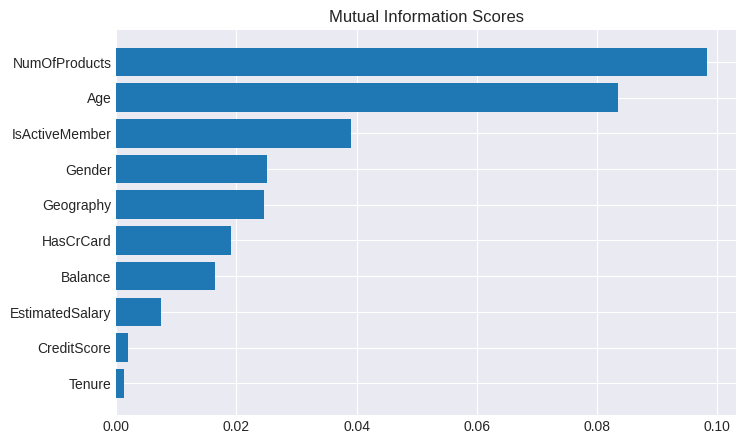

In [123]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")


plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_scores)

In [124]:
X_train_original = X_train.copy()
X_test_original = X_test.copy()

In [125]:
X_train.drop(columns=['Tenure','CreditScore'], inplace=True)
X_test.drop(columns=['Tenure', 'CreditScore'], inplace=True)

In [126]:
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# Model

## XGBoost

In [93]:
param_grid = {
    'learning_rate': [0.01, 0.001, 0.1],
    'max_depth': [3, 5, 6, 7],
    'n_estimators': [300, 400, 500],
    'reg_lambda': [1, 5, 10],
    'gamma': [0.2, 0.5, 1, 5, 0],
    'scale_pos_weight': [3, 4],
}

In [94]:
clf_xgb = XGBClassifier(objective='binary:logistic',
                             seed=42,
                             tree_method='hist',
                             device='cuda'
                        )

# Perform grid search
grid_search = GridSearchCV(clf_xgb, param_grid, cv=3, scoring='roc_auc', verbose=2)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
best_score = grid_search.best_score_

In [95]:
best_params

{'gamma': 0.2,
 'learning_rate': 0.05,
 'max_depth': 7,
 'n_estimators': 300,
 'reg_lambda': 10,
 'scale_pos_weight': 3}

In [96]:
best_score

0.9615454950644945

In [ ]:
clf_xgb = XGBClassifier(objective='binary:logistic',
                            gamma = 1,
                            learning_rate=0.1,
                            max_depth=3,
                            n_estimators=300,
                            reg_lambda=5,
                            scale_pos_weight=4,
                            early_stopping_rounds=10,
                            eval_metric=['auc', 'error'],
                            seed=42,
                            tree_method='hist',
                        )
clf_xgb.fit(X_train,
            y_train,
            verbose=True,
            eval_set=[(X_train, y_train), (X_val, y_val)])

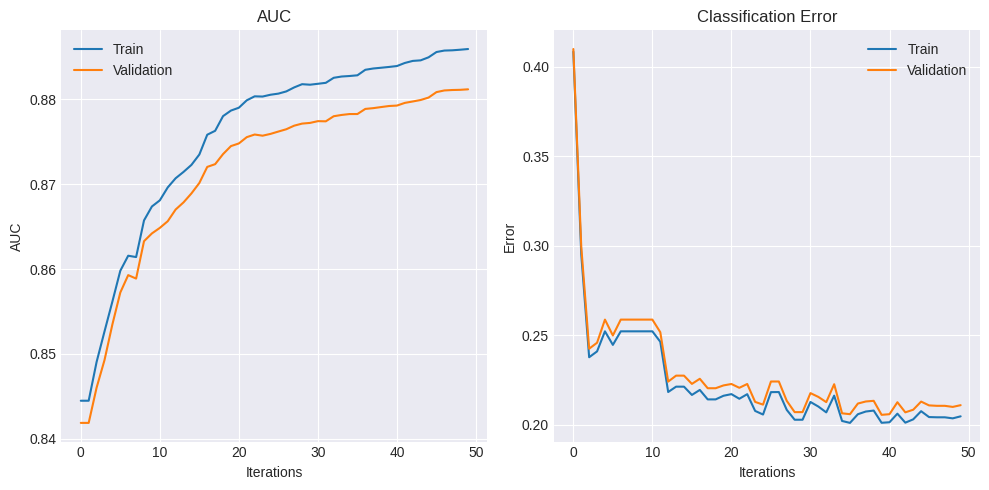

In [128]:
# Get the evaluation results
results = clf_xgb.evals_result()

# Extract the performance metrics for training set
train_auc = results['validation_0']['auc']
train_error = results['validation_0']['error']

# Check if there's only one validation set
if 'validation_1' in results:
    val_auc = results['validation_1']['auc']
    val_error = results['validation_1']['error']
else:
    # Set validation performance metrics to empty lists
    val_auc = []
    val_error = []

# Plot the performance graph
plt.figure(figsize=(10, 5))

# Plot AUC
plt.subplot(1, 2, 1)
plt.plot(train_auc, label='Train')
plt.plot(val_auc, label='Validation')
plt.title('AUC')
plt.xlabel('Iterations')
plt.ylabel('AUC')
plt.legend()

# Plot classification error
plt.subplot(1, 2, 2)
plt.plot(train_error, label='Train')
plt.plot(val_error, label='Validation')
plt.title('Classification Error')
plt.xlabel('Iterations')
plt.ylabel('Error')
plt.legend()

plt.tight_layout()
plt.show()

In [129]:
y_pred = clf_xgb.predict(X_test)

In [130]:
print('Accuracy', round(accuracy_score(y_test, y_pred), 3))
print('ROC_AUC', round(roc_auc_score(y_test, y_pred), 3))
print('F1', round(f1_score(y_test, y_pred), 3))

Accuracy 0.804
ROC_AUC 0.806
F1 0.63


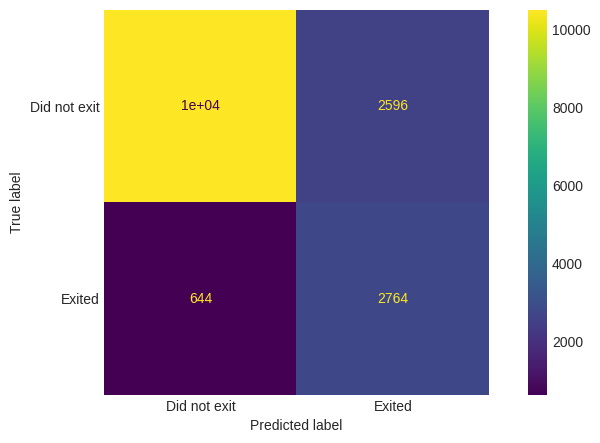

In [131]:
fig, ax = plt.subplots(figsize=(10, 5))

cm = confusion_matrix(y_test, y_pred, labels=clf_xgb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=['Did not exit', 'Exited'])
disp.plot(ax=ax)
ax.grid(False)
plt.show()

In [132]:
print(classification_report(y_test, y_pred, target_names=['Did not exit', 'Exited']))

              precision    recall  f1-score   support

Did not exit       0.94      0.80      0.87     13082
      Exited       0.52      0.81      0.63      3408

    accuracy                           0.80     16490
   macro avg       0.73      0.81      0.75     16490
weighted avg       0.85      0.80      0.82     16490



<Figure size 1000x600 with 0 Axes>

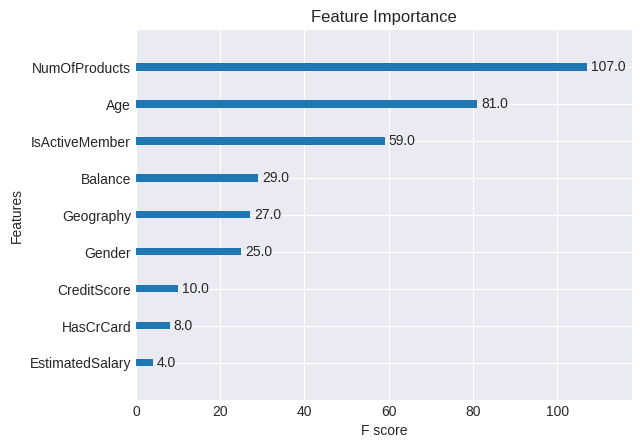

In [133]:
# Plot feature importance
plt.figure(figsize=(10, 6))
plot_importance(clf_xgb, importance_type='weight')
plt.title('Feature Importance')
plt.show()

## CatBoost

### Preprocess data

In [33]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,
0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [34]:
cat_features=["Gender", "Geography"]

In [35]:
X = df.drop(columns=["Exited"])
y = df["Exited"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=["Exited"]), df["Exited"], test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [37]:
y_train.value_counts()

0    103864
1     28050
Name: Exited, dtype: int64

### Base Model

In [38]:
params = {
    'iterations': 500,
    'learning_rate': 0.1,
    'custom_loss': metrics.AUC(),
    'eval_metric': metrics.Accuracy(),
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 40,
    'scale_pos_weight': 4,
    'logging_level': 'Silent',
    'use_best_model': False
}
train_pool = Pool(X_train, y_train, cat_features=cat_features)
validate_pool = Pool(X_val, y_val, cat_features=cat_features)

In [39]:
model = CatBoostClassifier(**params)
model.fit(train_pool, eval_set=validate_pool)

best_model_params = params.copy()
best_model_params.update({
    'use_best_model': True
})
best_model = CatBoostClassifier(**best_model_params)
best_model.fit(train_pool, eval_set=validate_pool);

print('Simple model validation accuracy: {:.4}'.format(
    accuracy_score(y_val, model.predict(X_val))
))
print('')

print('Best model validation accuracy: {:.4}'.format(
    accuracy_score(y_val, best_model.predict(X_val))
))

Simple model validation accuracy: 0.8014

Best model validation accuracy: 0.8018


In [40]:
y_pred = best_model.predict(X_test)

In [41]:
print(classification_report(y_test, y_pred, target_names=['Did not exit', 'Exited']))

              precision    recall  f1-score   support

Did not exit       0.94      0.80      0.87     13082
      Exited       0.52      0.81      0.63      3408

    accuracy                           0.80     16490
   macro avg       0.73      0.81      0.75     16490
weighted avg       0.85      0.80      0.82     16490



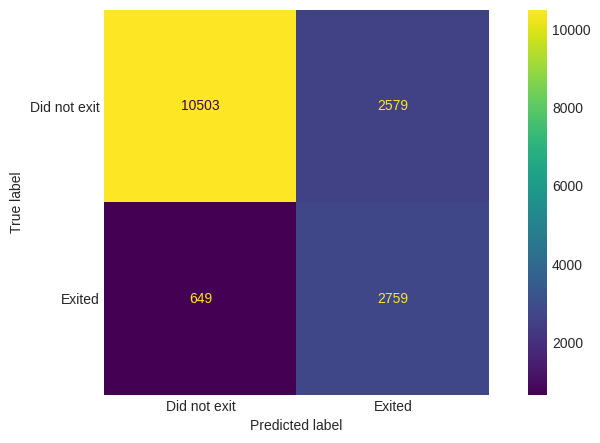

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))

cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=['Did not exit', 'Exited'])
disp.plot(ax=ax)
ax.grid(False)
plt.show()

### Hypertuning

In [58]:
tunedCat = CatBoostClassifier(loss_function='Logloss', random_state=42)

In [59]:
params_distribution = {
    'learning_rate': stats.uniform(0.01, 0.1),
    'depth': list(range(3, 10)),
    'l2_leaf_reg': stats.uniform(1, 10),
    'boosting_type': ['Ordered', 'Plain'],
}
train_pool = Pool(X_train, y_train, cat_features=cat_features)
validate_pool = Pool(X_val, y_val, cat_features=cat_features)

In [66]:
random_search_model = CatBoostClassifier(random_seed=42)
random_search_result = random_search_model.randomized_search(
    params_distribution,
    train_pool,
    n_iter=20,
    verbose=5,
    partition_random_seed=123)

print("Best Hyperparameters:", random_search_result.best_params_)

In [62]:
print("Best Hyperparameters:", random_search_result['params'])

Best Hyperparameters: {'boosting_type': 'Ordered', 'depth': 8, 'learning_rate': 0.09428538898501951, 'l2_leaf_reg': 9.902962008338516}


Best Hyperparameters: {'boosting_type': 'Ordered', 'depth': 8, 'learning_rate': 0.09428538898501951, 'l2_leaf_reg': 9.902962008338516}

In [67]:
params = {
    'iterations': 500,
    'l2_leaf_reg': 10,
    'boosting_type': 'Ordered',
    'depth': 8,
    'learning_rate': 0.09,
    'custom_loss': metrics.AUC(),
    'eval_metric': metrics.AUC(),
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 40,
    'scale_pos_weight': 4,
    'logging_level': 'Silent',
    'use_best_model': False
}
train_pool = Pool(X_train, y_train, cat_features=cat_features)
validate_pool = Pool(X_val, y_val, cat_features=cat_features)

In [71]:
tuned_model = CatBoostClassifier(**params)
tuned_model.fit(train_pool, eval_set=validate_pool)

tuned_best_model_params = params.copy()
tuned_best_model_params.update({
    'use_best_model': True
})
tuned_best_model = CatBoostClassifier(**tuned_best_model_params)
tuned_best_model.fit(train_pool, eval_set=validate_pool);

print('Simple model validation accuracy: {:.4}'.format(
    accuracy_score(y_val, tuned_model.predict(X_val))
))
print('')

print('Best model validation accuracy: {:.4}'.format(
    accuracy_score(y_val, tuned_best_model.predict(X_val))
))

Simple model validation accuracy: 0.8044

Best model validation accuracy: 0.8042


In [72]:
y_pred = tuned_best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Did not exit', 'Exited']))

              precision    recall  f1-score   support

Did not exit       0.94      0.81      0.87     13082
      Exited       0.52      0.81      0.63      3408

    accuracy                           0.81     16490
   macro avg       0.73      0.81      0.75     16490
weighted avg       0.85      0.81      0.82     16490



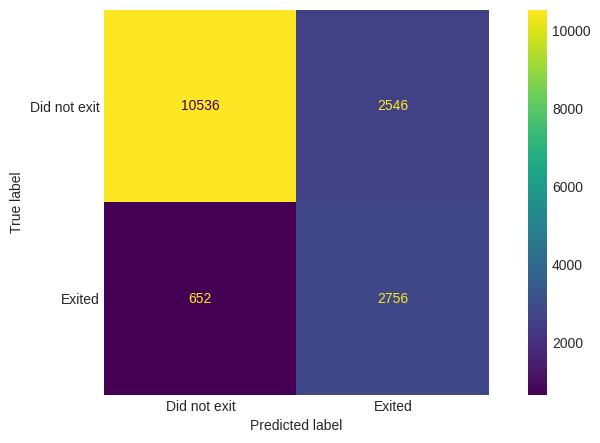

In [73]:
fig, ax = plt.subplots(figsize=(10, 5))

cm = confusion_matrix(y_test, y_pred, labels=tuned_best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=['Did not exit', 'Exited'])
disp.plot(ax=ax)
ax.grid(False)
plt.show()

In [74]:
importances = tuned_best_model.get_feature_importance(type='PredictionValuesChange')
feature_importances = pd.Series(importances, index=X.columns).sort_values()

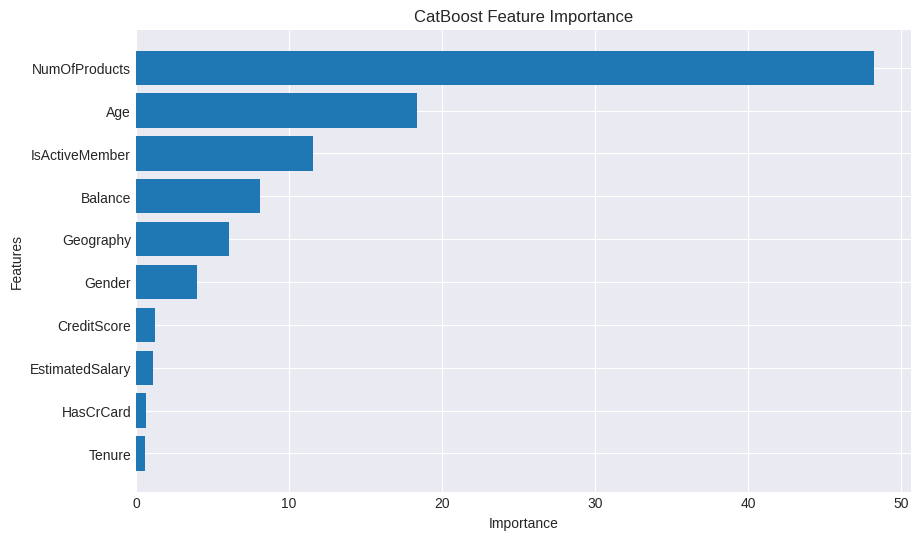

In [75]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importances.index, feature_importances.values)
plt.title('CatBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()
